# Consensus across rewiring: Life-like rules of resolution 5–10 vs Watts' majority

## 1. Question and setup

**Questions.** On Watts–Strogatz networks, from the ring lattice ($p = 0$) to random graphs ($p = 1$):
1. per resolution $r$, how does the best quiescent self-symmetric rule $\phi^r_{\beta,\sigma}$ compare with Watts' majority rule, as a function of $p$?
2. how are the rules of each resolution spread over the outcome classes (consensus always, sometimes, never)?
3. how long does consensus take?
4. which rules win in which rewiring regime, and is the best rule the same at every $p$?

**Setup** (defaults of `consensus_sweep.py`; the values actually used are read from the result files below):

| | |
|---|---|
| rules | every quiescent self-symmetric code of resolution $r = 5, \dots, 10$, even $r$ in both conventions `+-` and `-+`: 1680 codes |
| baseline | Watts' majority rule: alive if $\rho > 1/2$, dead if $\rho < 1/2$, a fair coin at $\rho = 1/2$ |
| networks | `networkx.connected_watts_strogatz_graph(N, k, p, seed)` with $N = 1000$, $k = 8$; $p = 0$ and 20 values log-spaced from $10^{-3}$ to $1$ |
| initial states | exactly $N/2$ living nodes ($\rho^0 = 1/2$); one configuration per network, shared by every rule and by majority |
| measured | consensus time $t_c$, the first timestep at which all nodes agree, up to $T_\text{max} = 10^5$; for a deterministic run without consensus, a proven cycle if one is found |
| discovery | $S = 100$ networks per $p$, every rule; the winners are **selected** here |
| validation | $V = 500$ fresh networks per $p$ (other seeds, other initial states), only the selected winners plus five tracked codes; the winners are **measured** here |
| majority | run on the discovery and on the validation networks, from the same initial states as the rules (paired) |

**Why two stages.** The best of 1680 rules on 100 networks looks better than it is (the winner's curse): the maximum picks up the luck of those 100 runs. Every claim about the selected winners therefore uses the fresh validation networks; discovery numbers for winners appear only as the selection step, drawn dashed. The landscape (section 4) describes all codes on the discovery networks, where nothing is selected.

**Running the sweep.** This notebook only reads results: it simulates nothing and re-executes in seconds. The results come from
```
caffeinate -i python notebooks/consensus_sweep.py
```
which writes `notebooks/results/` in three stages (discovery, selection, validation) and takes hours. It is resumable: existing files are skipped. `python notebooks/consensus_sweep.py --smoke` makes a small end-to-end run in `notebooks/results_smoke/`; set `CONSENSUS_SWEEP_RESULTS=results_smoke` to analyse that one. The notebook works on whatever files exist and reports what is missing.

In [1]:
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from IPython.display import Markdown, display
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
from scipy.stats import binomtest

import fast_llna as fl

RESULTS = Path(os.environ.get("CONSENSUS_SWEEP_RESULTS", "results"))  # relative to this notebook
RESOLUTIONS = range(5, 11)
CONV = ("+-", "-+")  # code rows are (r, conv, beta, sigma); conv 0 = "+-", 1 = "-+" (odd r: always 0)
OUTCOMES = ("t_consensus", "t_cycle", "state", "period")


def read(path):
    with np.load(path) as d:
        return {k: d[k] for k in d.files}


def load(prefix):
    """{p index: arrays} of the {prefix}_pII.npz files that exist."""
    out = {}
    for f in sorted(RESULTS.glob(f"{prefix}_p[0-9][0-9].npz")):
        d = read(f)
        assert f.name == f"{prefix}_p{int(d['i']):02d}.npz", f
        out[int(d["i"])] = d
    return out


def shared(files, keys):
    """Each key's value, asserted equal in every file."""
    files = list(files)
    for k in keys:
        assert all(np.array_equal(f[k], files[0][k]) for f in files), f"{k} differs between result files"
    return {k: files[0][k] for k in keys} if files else {}


disc, valid = load("disc"), load("valid")
vset = read(RESULTS / "validation_set.npz") if (RESULTS / "validation_set.npz").exists() else None
run = ["N", "K", "V", "T_MAX", "net_seeds", "seed_init", "seed_rules", "seed_majority", "codes"]
cfg_d, cfg_v = shared(disc.values(), ["S", *run]), shared(valid.values(), run)
for k in ("N", "K", "V", "T_MAX"):
    assert k not in cfg_d or k not in cfg_v or cfg_d[k] == cfg_v[k], f"{k} differs between discovery and validation"
if cfg_d and cfg_v:  # validation must be fresh: other networks, other initial states
    assert not np.intersect1d(cfg_d["net_seeds"], cfg_v["net_seeds"]).size
    assert cfg_d["seed_init"] != cfg_v["seed_init"] and cfg_d["seed_majority"] != cfg_v["seed_majority"]
if valid:
    assert vset is not None and np.array_equal(cfg_v["codes"], vset["codes"]), "lanes are not validation_set.npz"
cfg = {**cfg_v, **cfg_d}
N, K, V, T_MAX = (int(cfg[k]) if k in cfg else None for k in ("N", "K", "V", "T_MAX"))
S = int(cfg["S"]) if disc else None

P = {i: float(f["p"]) for files in (valid, disc) for i, f in files.items()}  # p of each p index
assert all(disc[i]["p"] == valid[i]["p"] for i in disc.keys() & valid.keys())
II_D, II_V = sorted(disc), sorted(valid)  # p indices with discovery / validation files
VALID_OK = bool(valid)  # validated numbers need the validation files and validation_set.npz

known = set(P) | (set(vset["pick_i"].tolist()) if vset is not None else set())
n_grid = max(known) + 1 if known else 0
missing = lambda have: ", ".join(str(i) for i in range(n_grid) if i not in have) or "none"
present = lambda have: ", ".join(map(str, sorted(have))) or "none"
lines = [f"**Results in `{RESULTS}/`**", "", "| stage | p indices present | missing |", "|---|---|---|",
         f"| discovery `disc_pII.npz` | {present(disc)} | {missing(disc)} |",
         f"| selection `validation_set.npz` | {'yes' if vset is not None else 'none'} | "
         f"{'' if vset is not None else 'the whole file'} |",
         f"| validation `valid_pII.npz` | {present(valid)} | {missing(valid)} |"]
if vset is None:
    lines.append(f"\nThe p grid is known only up to index {n_grid - 1}: `validation_set.npz`, which records picks "
                 "at every p, does not exist yet." if n_grid else "\nNo result files: every section below that "
                 "needs them is skipped.")
display(Markdown("\n".join(lines)))
if cfg:
    rows = [("N (nodes)", N), ("k (ring neighbours)", K), ("S (discovery networks per p)", S),
            ("V (validation networks per p)", V), ("T_max", f"{T_MAX:,}"),
            ("p values", ", ".join(f"{P[i]:.3g}" for i in sorted(P)))]
    if cfg_d:
        rows.append(("discovery seeds: networks, init, majority", f"{cfg_d['net_seeds'].min()}..{cfg_d['net_seeds'].max()}, "
                     f"{cfg_d['seed_init']}, {cfg_d['seed_majority']}"))
    if cfg_v:
        rows.append(("validation seeds: networks, init, majority", f"{cfg_v['net_seeds'].min()}..{cfg_v['net_seeds'].max()}, "
                     f"{cfg_v['seed_init']}, {cfg_v['seed_majority']}"))
    if vset is not None:
        rows.append(("validation set", f"{len(vset['codes'])} codes ({vset['tracked'].sum()} tracked); union of all "
                     f"picks {int(vset['n_union'])}, fallback to rank-1 picks: {bool(vset['fallback'])}"))
    display(Markdown("| config (read from the files) | |\n|---|---|\n" + "\n".join(f"| {a} | {b} |" for a, b in rows)))

**Results in `results/`**

| stage | p indices present | missing |
|---|---|---|
| discovery `disc_pII.npz` | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20 | none |
| selection `validation_set.npz` | yes |  |
| validation `valid_pII.npz` | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20 | none |

| config (read from the files) | |
|---|---|
| N (nodes) | 1000 |
| k (ring neighbours) | 8 |
| S (discovery networks per p) | 100 |
| V (validation networks per p) | 500 |
| T_max | 100,000 |
| p values | 0, 0.001, 0.00144, 0.00207, 0.00298, 0.00428, 0.00616, 0.00886, 0.0127, 0.0183, 0.0264, 0.0379, 0.0546, 0.0785, 0.113, 0.162, 0.234, 0.336, 0.483, 0.695, 1 |
| discovery seeds: networks, init, majority | 0..99, 1, 2 |
| validation seeds: networks, init, majority | 1000..1499, 11, 12 |
| validation set | 52 codes (5 tracked); union of all picks 52, fallback to rank-1 picks: False |

**Helpers** for the plots and statistics below:
- every plot against $p$ uses a log axis; $p = 0$ cannot sit on it, so it is drawn on its own at the far left, beyond a dotted break, and not joined to the other points;
- one colour per resolution $r$, black for Watts' majority;
- `wilson`: 95% Wilson interval of a fraction; `holm`: Holm's step-down adjustment of a family of $p$-values.

In [2]:
R_COLOR = dict(zip(RESOLUTIONS, plt.cm.viridis(np.linspace(0, 0.88, len(RESOLUTIONS))), strict=True))
P_POS = sorted(p for p in P.values() if p > 0)
X0 = P_POS[0] / 4 if P_POS else 1e-4  # where p = 0 is drawn


def fmt_p(p):
    return f"{p:.3g}"


def xp(p):
    return np.where(np.asarray(p) == 0, X0, p)


def p_axis(ax):
    """Log x axis over the p > 0 values, with p = 0 at X0 beyond a dotted break."""
    ax.set_xscale("log")
    lo, hi = (P_POS[0], P_POS[-1]) if P_POS else (1, 1)
    ticks = [t for t in 10.0 ** np.arange(-9, 1) if lo / 1.6 <= t <= hi * 1.6]
    labels = [f"$10^{{{round(np.log10(t))}}}$" for t in ticks]
    if len(ticks) < 2:  # a sparse grid (partial results): label the p values themselves
        ticks, labels = P_POS, [fmt_p(p) for p in P_POS]
    ax.set_xticks([X0, *ticks], ["0", *labels])
    ax.xaxis.set_minor_locator(plt.NullLocator())
    ax.axvline(X0 * 2, color="0.6", lw=0.8, ls=":")
    ax.set_xlim(X0 / 1.6, 1.6 * max(P_POS, default=1))
    ax.set_xlabel("rewiring probability $p$")


def plot_p(ax, p, y, **kw):
    """y against p, with the p = 0 point drawn on its own (not joined to p > 0)."""
    p, y = np.asarray(p), np.asarray(y, float)
    pos = p > 0
    (line,) = ax.plot(p[pos], y[pos], marker="o", ms=3, **kw)
    if (~pos).any():
        ax.plot(np.full((~pos).sum(), X0), y[~pos], ls="none", marker="o", ms=3, color=line.get_color(),
                mfc=line.get_markerfacecolor(), alpha=line.get_alpha())
    return line


def errbar_p(ax, p, y, lo, hi, color):
    ax.errorbar(xp(p), y, yerr=[np.subtract(y, lo), np.subtract(hi, y)], fmt="none", ecolor=color, elinewidth=0.8)


def band_p(ax, p, lo, hi, color, alpha=0.15, **kw):
    """A shaded interval over the p > 0 points, and a wide bar at p = 0."""
    p, lo, hi = np.asarray(p), np.asarray(lo), np.asarray(hi)
    pos = p > 0
    ax.fill_between(p[pos], lo[pos], hi[pos], color=color, alpha=alpha, lw=0, **kw)
    ax.vlines(np.full((~pos).sum(), X0), lo[~pos], hi[~pos], color=color, alpha=alpha, lw=6)


def frac_axis(ax, linthresh):
    """Symmetric-log y axis for fractions in [0, 1]: linear below linthresh, so small fractions stay visible."""
    ax.set_yscale("symlog", linthresh=linthresh, linscale=0.3)
    ticks = [0, *10.0 ** np.arange(np.log10(linthresh), 1)]
    ax.set_yticks(ticks, [f"{t:g}" for t in ticks])
    ax.yaxis.set_minor_locator(plt.NullLocator())
    ax.set_ylim(0, 1.3)


def wilson(k, n):
    ci = binomtest(int(k), int(n)).proportion_ci(method="wilson")
    return ci.low, ci.high


def holm(pvals):
    """Holm-adjusted p-values (family = all entries)."""
    p = np.asarray(pvals, float)
    order = np.argsort(p)
    adj = np.minimum(np.maximum.accumulate((len(p) - np.arange(len(p))) * p[order]), 1)
    out = np.empty_like(p)
    out[order] = adj
    return out


assert np.allclose(holm([0.01, 0.04, 0.03]), [0.03, 0.06, 0.06]) and np.allclose(holm([0.5, 0.9]), [1, 1])


def name(code, md=False):
    """phi^r_{beta,sigma}, with the convention for even r (backticks in Markdown)."""
    r, conv, b, s = (int(x) for x in code)
    tag = "" if r % 2 else (f" `{CONV[conv]}`" if md else f" {CONV[conv]}")
    return rf"$\phi^{{{r}}}_{{{b},{s}}}$" + tag


def lane(r, i, rank=1):
    """Validation-set index of the rank-`rank` discovery pick for (r, p index i); r = 0: over all r. None: no
    pick (no behaviour with a code of resolution r reached consensus on any discovery network)."""
    m = (vset["pick_r"] == r) & (vset["pick_i"] == i) & (vset["pick_rank"] == rank)
    assert m.sum() <= 1
    return int(vset["pick_code"][m][0]) if m.any() else None


def show_rule(ax, code):
    """Response diagram (black = alive at the next step) per density cell; red marks rho = 1/2."""
    r, conv, b, s = (int(x) for x in code)
    cells = np.arange(r)
    ax.imshow([(b >> cells) & 1, (s >> cells) & 1], cmap="Greys", vmin=0, vmax=1)
    if r % 2:  # odd r: the closed central cell contains rho = 1/2
        ax.add_patch(Rectangle(((r - 1) / 2 - 0.5, -0.5), 1, 2, fill=False, ec="tab:red", lw=2))
    else:  # even r: rho = 1/2 is the edge between cells r/2 - 1 and r/2
        ax.axvline(r / 2 - 0.5, color="tab:red", lw=2)
    ax.set(xticks=cells, yticks=[0, 1], yticklabels=["dead (B)", "alive (S)"])

## 2. Rules per resolution

Resolution $r$ splits the density interval $[0, 1]$ into $r$ cells $R_0, \dots, R_{r-1}$, mirrored around $\rho = 1/2$. Rule $\phi^r_{\beta,\sigma}$ makes a dead node in cell $R_j$ alive if bit $j$ of $\beta$ is set, and keeps a living node alive if bit $j$ of $\sigma$ is set (details in `consensus_r9.ipynb` and `consensus_r8.ipynb`).
- **Self-symmetric**: the rule commutes with complementing every state exactly when $\sigma = 2^r - 1 - \overline{\beta}$, where $\overline{\beta}$ reverses the $r$ bits of $\beta$. So $\beta$ is free: $2^r$ rules (`fl.self_equivalent(r)`).
- **Quiescent**: a dead node without living neighbours stays dead ($\beta_0 = 0$). By self-symmetry a living node among living neighbours then stays alive, so both uniform states are fixed points and consensus, once reached, stays. That keeps $2^{r-1}$ rules; the other half are output complements with the same consensus times.
- **Even $r$** puts $\rho = 1/2$ on the edge between $R_{r/2-1}$ and $R_{r/2}$. The two conventions `+-` and `-+` assign that edge differently for dead and living nodes, and both are swept. A code with $\beta_{r/2-1} = \beta_{r/2}$ reads the same bits at a tie in either convention, so it is the same rule twice.

A **code** is a row $(r, \text{convention}, \beta, \sigma)$. The table is rebuilt from the package and compared with the codes stored in the result files.

In [3]:
blocks, lines, DISTINCT = [], [], {}
for r in RESOLUTIONS:
    se = fl.self_equivalent(r)  # [2^r, 2] rows (beta, sigma), sigma = 2^r - 1 - mirror(beta)
    q = se[se[:, 0] % 2 == 0]  # quiescent: beta_0 = 0
    convs = (0, 1) if r % 2 == 0 else (0,)
    blocks += [np.column_stack([np.full((len(q), 2), (r, c)), q]) for c in convs]
    twins = int(np.sum((q[:, 0] >> (r // 2 - 1) & 1) == (q[:, 0] >> (r // 2) & 1))) if r % 2 == 0 else 0
    DISTINCT[r] = len(q) * len(convs) - twins
    lines.append(f"| {r} | {' '.join(f'`{CONV[c]}`' for c in convs)} | {len(se)} | {len(q)} | {len(q) * len(convs)} "
                 f"| {twins if r % 2 == 0 else '–'} | {DISTINCT[r]} |")
CODES = np.concatenate(blocks)  # ordered by r, convention, beta: the order of the result files
lines.append(f"| all | | | | {len(CODES)} | | {sum(DISTINCT.values())} |")
display(Markdown("| $r$ | conventions | self-symmetric per convention | quiescent per convention | codes "
                 "| same rule in both conventions | distinct rules of $r$ |\n|---|---|---|---|---|---|---|\n"
                 + "\n".join(lines)))

if disc:
    assert np.array_equal(cfg_d["codes"], CODES)
    print(f"the {len(CODES)} codes stored in the discovery files equal the package's, in the same order")
CODE_INDEX = {tuple(c): j for j, c in enumerate(CODES.tolist())}
if vset is not None:
    VIDX = np.array([CODE_INDEX[tuple(c)] for c in vset["codes"].tolist()])  # validation lane -> code index
    assert np.all(np.diff(VIDX) > 0)
    print(f"the {len(VIDX)} validation-set codes are package codes, in code order")

| $r$ | conventions | self-symmetric per convention | quiescent per convention | codes | same rule in both conventions | distinct rules of $r$ |
|---|---|---|---|---|---|---|
| 5 | `+-` | 32 | 16 | 16 | – | 16 |
| 6 | `+-` `-+` | 64 | 32 | 64 | 16 | 48 |
| 7 | `+-` | 128 | 64 | 64 | – | 64 |
| 8 | `+-` `-+` | 256 | 128 | 256 | 64 | 192 |
| 9 | `+-` | 512 | 256 | 256 | – | 256 |
| 10 | `+-` `-+` | 1024 | 512 | 1024 | 256 | 768 |
| all | | | | 1680 | | 1344 |

the 1680 codes stored in the discovery files equal the package's, in the same order
the 52 validation-set codes are package codes, in code order


### Self-checks on the result files

1. Configs agree across files, and validation uses other network seeds and initial states than discovery (asserted when loading).
2. The validation lanes are exactly the codes of `validation_set.npz` (asserted when loading).
3. Behaviour ids are consistent: each behaviour's representative is its first code, and ids are ordered by representative.
4. Per-code results equal behaviour results mapped through `behaviour`: on the validation networks, validation codes that share a discovery behaviour (identical tables on the discovery **and** validation degrees) have identical runs.
5. Each rank-1 discovery pick has the best discovery fraction of its resolution (the "discovery best" curve below), and there is no pick exactly where no code of that resolution reached consensus.

In [4]:
FRAC_DISC = {i: np.isfinite(d["t_consensus"]).mean(0)[d["behaviour"]] for i, d in disc.items()}  # per code
for i, d in disc.items():
    beh, rep = d["behaviour"], d["rep"]
    assert np.array_equal(np.unique(beh, return_index=True)[1], rep), i  # rep = first code; ids in rep order
    assert np.all(np.diff(rep) > 0) and np.array_equal(beh[rep], np.arange(len(rep)))
n_pairs = 0
for i in sorted(disc.keys() & valid.keys()):
    d, v = disc[i], valid[i]
    assert np.isin(v["degrees"], d["degrees"]).all()  # behaviours were computed on these degrees too
    _, first, inv = np.unique(d["behaviour"][VIDX], return_index=True, return_inverse=True)
    for key in OUTCOMES:
        assert np.array_equal(v[key], v[key][:, first[inv.ravel()]]), (i, key)
    n_pairs += len(VIDX) - len(first)
if disc and vset is not None:
    for i in II_D:
        for r in (0, *RESOLUTIONS):
            of_r = slice(None) if r == 0 else CODES[:, 0] == r
            best, pick = FRAC_DISC[i][of_r].max(), lane(r, i)
            assert (pick is None) == (best == 0), (r, i)
            assert pick is None or FRAC_DISC[i][VIDX[pick]] == best, (r, i)
both = len(disc.keys() & valid.keys())
print(f"check 3 passes on {len(disc)} discovery files; check 4 on {both} p values with both stages ({n_pairs} "
      f"validation lanes share another lane's behaviour and match it run for run); check 5 "
      + (f"on {len(disc)} p values" if disc and vset is not None else "not run (needs discovery files and validation_set.npz)"))

check 3 passes on 21 discovery files; check 4 on 21 p values with both stages (79 validation lanes share another lane's behaviour and match it run for run); check 5 on 21 p values


## 3. Resolution acts only through degree

A node's next state depends on its own state $s$, its degree $k$ and its number $q$ of living neighbours. On a graph whose degrees are a set $D$, a rule is therefore just a table over $(s, k \in D, q = 0..k)$, and codes with the same table are the same dynamics, whatever their resolution. The sweep calls such a class a **behaviour** and simulates it once.

**At $p = 0$** the network is the 8-regular ring lattice. A quiescent self-symmetric table at $k = 8$ is fixed by the births at $q = 1, \dots, 8$ (quiescence fixes $q = 0$, self-symmetry fixes the survivals), so every quiescent self-symmetric rule of $r = 5, \dots, 10$ is one of only $2^8 = 256$ functions. Resolution 9 already realises all 256: at $k = 8$ its cells separate every $q = 0, \dots, 8$. All 1680 codes collapse to 256 behaviours there.

**At small $p$** most nodes still have degree 8 (last column). Rules that agree at degree 8 differ only on the few other nodes, so differences between resolutions at low $p$ come entirely from those nodes. The line below the table gives the number of distinct behaviours at each $p > 0$ present, read from the files.

The table counts behaviours among the codes of each resolution; the degree range is over the discovery and validation networks (the degrees the behaviours were computed on), and the degree-8 fraction is recomputed from the discovery networks' seeds.

In [5]:
if not disc:
    print("section 3 skipped: no discovery files")
else:
    start = time.perf_counter()
    lines = ["| $p$ | " + " | ".join(f"$r = {r}$" for r in RESOLUTIONS) + f" | all | degrees | degree-{K} nodes |",
             "|---" * (len(RESOLUTIONS) + 4) + "|",
             "| *codes* | " + " | ".join(str(np.sum(CODES[:, 0] == r)) for r in RESOLUTIONS) + f" | *{len(CODES)}* | | |",
             "| *distinct rules of $r$* | " + " | ".join(str(DISTINCT[r]) for r in RESOLUTIONS) + " | | | |"]
    n_beh = {}
    for i in II_D:
        d = disc[i]
        n_beh[i] = [len(np.unique(d["behaviour"][CODES[:, 0] == r])) for r in RESOLUTIONS]
        deg = np.concatenate([[k for _, k in nx.connected_watts_strogatz_graph(N, K, P[i], seed=int(s)).degree()]
                              for s in d["net_seeds"]])
        assert np.isin(deg, d["degrees"]).all()
        lines.append(f"| {fmt_p(P[i])} | " + " | ".join(map(str, n_beh[i])) + f" | {len(d['rep'])} | "
                     f"{d['degrees'].min()}–{d['degrees'].max()} | {np.mean(deg == K):.3f} |")
    display(Markdown("\n".join(lines)))
    print(f"{len(II_D) * S} discovery networks regenerated in {time.perf_counter() - start:.1f} s")
    n_pos = {fmt_p(P[i]): len(disc[i]["rep"]) for i in II_D if P[i] > 0}
    if n_pos:
        print(f"distinct behaviours among the {len(CODES)} codes at each p > 0 present: "
              + ", ".join(f"{n} at p = {p}" for p, n in n_pos.items()))
    for i in (i for i in II_D if P[i] == 0):  # the ring lattice: 2^K functions, all realised by r = K + 1
        assert len(disc[i]["rep"]) == 2**K and n_beh[i][list(RESOLUTIONS).index(K + 1)] == 2**K
        print(f"p = 0: the {len(CODES)} codes are {2**K} behaviours, and the r = {K + 1} codes realise all of them")

| $p$ | $r = 5$ | $r = 6$ | $r = 7$ | $r = 8$ | $r = 9$ | $r = 10$ | all | degrees | degree-8 nodes |
|---|---|---|---|---|---|---|---|---|---|
| *codes* | 16 | 64 | 64 | 256 | 256 | 1024 | *1680* | | |
| *distinct rules of $r$* | 16 | 48 | 64 | 192 | 256 | 768 | | | |
| 0 | 16 | 48 | 64 | 192 | 256 | 256 | 256 | 8–8 | 1.000 |
| 0.001 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 6–10 | 0.993 |
| 0.00144 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 6–10 | 0.989 |
| 0.00207 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–10 | 0.984 |
| 0.00298 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 6–10 | 0.976 |
| 0.00428 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 6–11 | 0.966 |
| 0.00616 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 6–11 | 0.952 |
| 0.00886 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–11 | 0.933 |
| 0.0127 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–12 | 0.906 |
| 0.0183 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–12 | 0.869 |
| 0.0264 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–12 | 0.819 |
| 0.0379 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 5–12 | 0.753 |
| 0.0546 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–13 | 0.674 |
| 0.0785 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–15 | 0.584 |
| 0.113 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–14 | 0.489 |
| 0.162 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–15 | 0.400 |
| 0.234 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–16 | 0.322 |
| 0.336 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–18 | 0.268 |
| 0.483 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–18 | 0.229 |
| 0.695 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–19 | 0.206 |
| 1 | 16 | 48 | 64 | 192 | 256 | 768 | 1317 | 4–20 | 0.196 |

2100 discovery networks regenerated in 4.0 s
distinct behaviours among the 1680 codes at each p > 0 present: 1317 at p = 0.001, 1317 at p = 0.00144, 1317 at p = 0.00207, 1317 at p = 0.00298, 1317 at p = 0.00428, 1317 at p = 0.00616, 1317 at p = 0.00886, 1317 at p = 0.0127, 1317 at p = 0.0183, 1317 at p = 0.0264, 1317 at p = 0.0379, 1317 at p = 0.0546, 1317 at p = 0.0785, 1317 at p = 0.113, 1317 at p = 0.162, 1317 at p = 0.234, 1317 at p = 0.336, 1317 at p = 0.483, 1317 at p = 0.695, 1317 at p = 1
p = 0: the 1680 codes are 256 behaviours, and the r = 9 codes realise all of them


## 4. Landscape: how the rules of each resolution behave

On the $S$ discovery networks, each code falls into one class per $p$ (through its behaviour):
- **consensus in every run**, or **in some runs**;
- **never: every run cycles**: every run entered a cycle without consensus, which proves that none of these $S$ runs ever reaches consensus;
- **never by $T_\text{max}$: some runs open**: no consensus, and at least one run neither reached consensus nor showed a cycle by $T_\text{max}$.

Fractions are of codes, so for even $r$ a rule shared by both conventions counts twice. The second figure counts runs instead: over all codes of resolution $r$ and all $S$ networks, the fraction that reached consensus, cycled, or was still open at $T_\text{max}$. Majority is stochastic, so it has no cycles: its runs reach consensus or stay open. The class fractions and the run-level consensus fraction are drawn on symmetric-log axes (linear below $10^{-3}$ for codes, $10^{-4}$ for runs), so that rare outcomes stay visible.

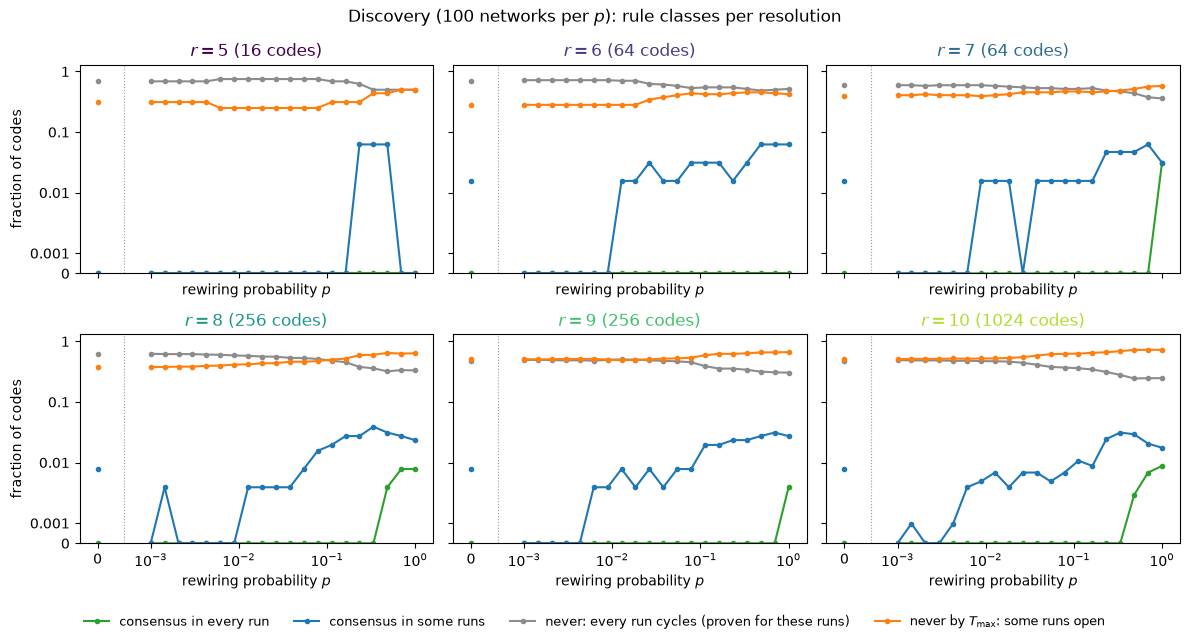

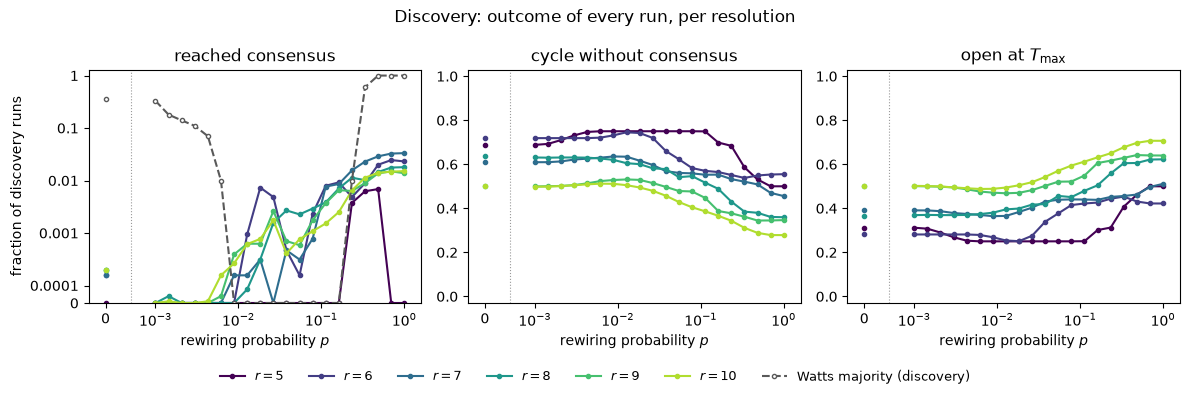

In [6]:
CLASSES = ("consensus in every run", "consensus in some runs", "never: every run cycles (proven for these runs)",
           r"never by $T_\mathrm{max}$: some runs open")
CLASS_COLOR = ("tab:green", "tab:blue", "0.55", "tab:orange")
if not disc:
    print("section 4 skipped: no discovery files")
else:
    pD = np.array([P[i] for i in II_D])
    cls_frac = np.zeros((len(II_D), len(RESOLUTIONS), 4))  # [p, r, class]: fraction of the codes of r
    run_frac = np.zeros((len(II_D), len(RESOLUTIONS), 3))  # [p, r, consensus / cycle / open]: fraction of runs
    for j, i in enumerate(II_D):
        d = disc[i]
        con, cyc = np.isfinite(d["t_consensus"]), np.isfinite(d["t_cycle"])
        assert not (con & cyc).any()
        n_con, n_cyc = con.sum(0)[d["behaviour"]], cyc.sum(0)[d["behaviour"]]  # per code
        cls = np.select([n_con == S, n_con > 0, n_cyc == S], [0, 1, 2], 3)  # 3: no consensus, some run open
        for k, r in enumerate(RESOLUTIONS):
            m = CODES[:, 0] == r
            cls_frac[j, k] = np.bincount(cls[m], minlength=4) / m.sum()
            run_frac[j, k] = [n_con[m].sum(), n_cyc[m].sum(), (S - n_con - n_cyc)[m].sum()]
            run_frac[j, k] /= S * m.sum()
    maj_disc = np.array([np.isfinite(disc[i]["maj_t_consensus"]).mean() for i in II_D])

    fig, axes = plt.subplots(2, 3, figsize=(12, 6.4), sharex=True, sharey=True)
    for ax, (k, r) in zip(axes.flat, enumerate(RESOLUTIONS), strict=True):
        for c in range(4):
            plot_p(ax, pD, cls_frac[:, k, c], color=CLASS_COLOR[c], label=CLASSES[c])
        ax.set_title(f"$r = {r}$ ({np.sum(CODES[:, 0] == r)} codes)", color=R_COLOR[r])
        p_axis(ax)
        frac_axis(ax, 1e-3)
    for ax in axes[:, 0]:
        ax.set_ylabel("fraction of codes")
    fig.legend(*axes[0, 0].get_legend_handles_labels(), loc="lower center", ncol=4, fontsize=9, frameon=False)
    fig.suptitle(f"Discovery ({S} networks per $p$): rule classes per resolution")
    fig.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.9))
    for k, r in enumerate(RESOLUTIONS):
        for o, ax in enumerate(axes):
            plot_p(ax, pD, run_frac[:, k, o], color=R_COLOR[r], label=f"$r = {r}$")
    plot_p(axes[0], pD, maj_disc, color="0.35", ls="--", mfc="w", label="Watts majority (discovery)")
    for ax, title in zip(axes, ("reached consensus", "cycle without consensus", r"open at $T_\mathrm{max}$"), strict=True):
        ax.set(title=title, ylim=(-0.03, 1.03))
        p_axis(ax)
    frac_axis(axes[0], 1e-4)  # consensus is rare: symmetric-log
    axes[0].set_ylabel("fraction of discovery runs")
    fig.legend(*axes[0].get_legend_handles_labels(), loc="lower center", ncol=7, fontsize=9, frameon=False)
    fig.suptitle("Discovery: outcome of every run, per resolution")
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

## 5. Best rule vs Watts' majority, per resolution

All curves are the fraction of runs in consensus by $T_\text{max}$:
- **discovery best** (dashed, colour of $r$): the maximum over the codes of resolution $r$ on the $S$ discovery networks. It is selected on the very runs it reports, so it is **biased upwards**; it shows the selection step only.
- **validated pick** (solid, 95% Wilson interval): the rank-1 discovery pick for $(r, p)$, chosen on discovery data only, measured on the $V$ fresh validation networks at the same $p$. This is the estimate to compare.
- **Watts' majority** (black): on the validation networks (solid, with interval) and on the discovery networks (dashed).

A missing validated point means no code of resolution $r$ reached consensus on any discovery network at that $p$, so there is no pick.

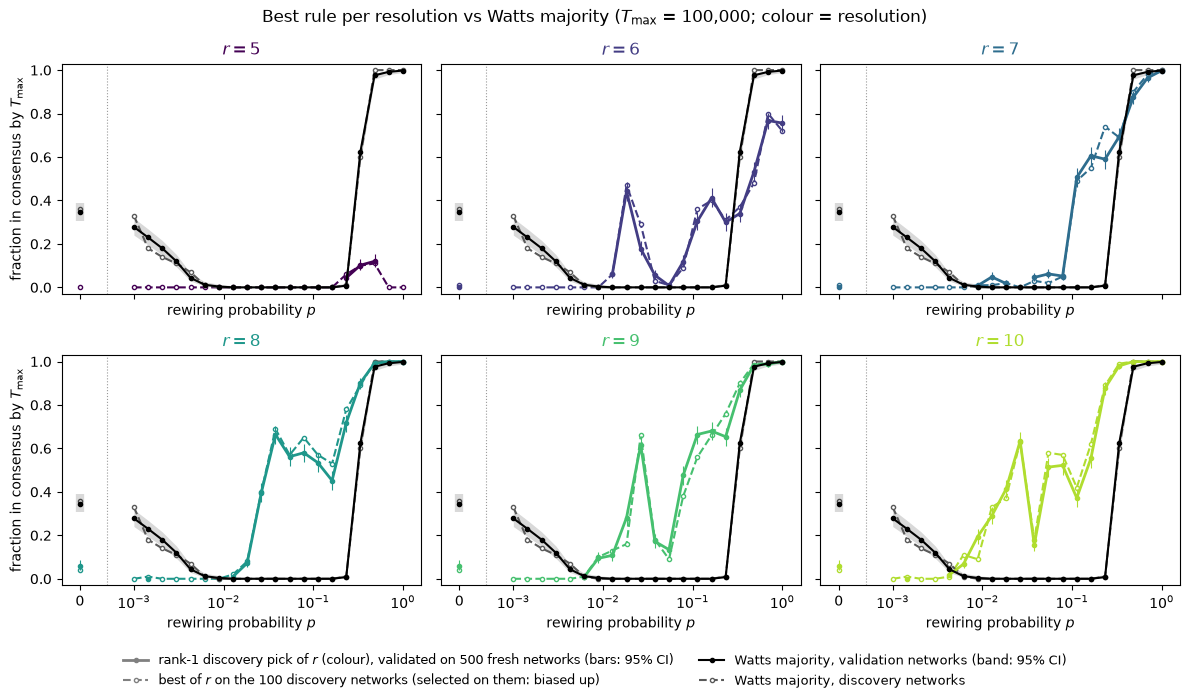

In [7]:
if not disc and not VALID_OK:
    print("section 5 skipped: no discovery or validation files")
else:
    pD, pV = np.array([P[i] for i in II_D]), np.array([P[i] for i in II_V])
    disc_best = {r: np.array([FRAC_DISC[i][CODES[:, 0] == r].max() for i in II_D]) for r in RESOLUTIONS}
    maj_disc = np.array([np.isfinite(disc[i]["maj_t_consensus"]).mean() for i in II_D])
    val_pick, val_ci = {}, {}  # r -> [p] validated fraction of the rank-1 pick (nan: no pick), [2, p] Wilson CI
    for r in RESOLUTIONS:
        k = [np.isfinite(valid[i]["t_consensus"][:, lane(r, i)]).sum() if lane(r, i) is not None else np.nan
             for i in II_V]
        val_pick[r] = np.array(k, float) / V
        val_ci[r] = np.array([wilson(x, V) if np.isfinite(x) else (np.nan, np.nan) for x in k]).T.reshape(2, -1)
    k_maj = [np.isfinite(valid[i]["maj_t_consensus"]).sum() for i in II_V]
    maj_val, maj_ci = np.array(k_maj) / (V or 1), np.array([wilson(x, V) for x in k_maj]).T.reshape(2, -1)

    fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True, sharey=True)
    for ax, r in zip(axes.flat, RESOLUTIONS, strict=True):
        if disc:
            plot_p(ax, pD, disc_best[r], color=R_COLOR[r], ls="--", mfc="w")
            plot_p(ax, pD, maj_disc, color="0.35", ls="--", mfc="w")
        if VALID_OK:
            plot_p(ax, pV, val_pick[r], color=R_COLOR[r], lw=2)
            errbar_p(ax, pV, val_pick[r], *val_ci[r], R_COLOR[r])
            plot_p(ax, pV, maj_val, color="k", lw=1.5)
            band_p(ax, pV, *maj_ci, "k")
        ax.set_title(f"$r = {r}$", color=R_COLOR[r])
        p_axis(ax)
    for ax in axes[:, 0]:
        ax.set_ylabel(r"fraction in consensus by $T_\mathrm{max}$")
    axes[0, 0].set_ylim(-0.03, 1.03)
    handles = [Line2D([], [], color="0.5", lw=2, marker="o", ms=3,
                      label=f"rank-1 discovery pick of $r$ (colour), validated on {V} fresh networks (bars: 95% CI)"),
               Line2D([], [], color="0.5", ls="--", marker="o", ms=3, mfc="w",
                      label=f"best of $r$ on the {S} discovery networks (selected on them: biased up)"),
               Line2D([], [], color="k", lw=1.5, marker="o", ms=3, label="Watts majority, validation networks (band: 95% CI)"),
               Line2D([], [], color="0.35", ls="--", marker="o", ms=3, mfc="w", label="Watts majority, discovery networks")]
    fig.legend(handles=handles, loc="lower center", ncol=2, fontsize=9, frameon=False)
    fig.suptitle(f"Best rule per resolution vs Watts majority ($T_\\mathrm{{max}}$ = {T_MAX:,}; colour = resolution)")
    fig.tight_layout(rect=(0, 0.07, 1, 1))
    plt.show()

**Paired comparison with majority.** On each validation network the rank-1 pick and majority start from the same configuration. A **win** is a network on which the rule reaches consensus earlier than majority, a **loss** one on which it is later; a run without consensus counts as $t_c = \infty$, and equal times (including both censored) are ties, which a sign test drops. Each cell gives the pick, wins : losses, and the two-sided sign-test $p$-value after Holm's correction across the $p$ values of that resolution (**bold**: below 0.05). The family is per resolution; there is no correction across resolutions. A $p$ without untied pairs has no test and is left out of the family.

In [8]:
if not VALID_OK:
    print("sign tests skipped: no validation files")
else:
    cells = {}  # (r, p index) -> cell text
    for r in RESOLUTIONS:
        tests = []  # (p index, pick, wins, losses, p-value)
        for i in II_V:
            pick = lane(r, i)
            if pick is None:
                cells[r, i] = "no pick"
                continue
            t, t_maj = valid[i]["t_consensus"][:, pick], valid[i]["maj_t_consensus"]
            won, lost = int((t < t_maj).sum()), int((t > t_maj).sum())
            tests.append((i, pick, won, lost, binomtest(won, won + lost).pvalue if won + lost else np.nan))
        pv = np.array([x[4] for x in tests])
        adj = np.full(len(pv), np.nan)
        adj[~np.isnan(pv)] = holm(pv[~np.isnan(pv)])
        for (i, pick, won, lost, _), a in zip(tests, adj, strict=True):
            ph = f"**{a:.2g}**" if a < 0.05 else f"{a:.2g}"
            stat = f"{won} : {lost}, " + ("no untied pair" if np.isnan(a) else f"$p_\\text{{Holm}}$ = {ph}")
            cells[r, i] = f"{name(vset['codes'][pick], md=True)}<br>{stat}"
    lines = ["| $p$ | " + " | ".join(f"$r = {r}$" for r in RESOLUTIONS) + " |", "|---" * (len(RESOLUTIONS) + 1) + "|"]
    lines += [f"| {fmt_p(P[i])} | " + " | ".join(cells[r, i] for r in RESOLUTIONS) + " |" for i in II_V]
    display(Markdown("\n".join(lines)))

| $p$ | $r = 5$ | $r = 6$ | $r = 7$ | $r = 8$ | $r = 9$ | $r = 10$ |
|---|---|---|---|---|---|---|
| 0 | no pick | $\phi^{6}_{36,54}$ `+-`<br>0 : 173, $p_\text{Holm}$ = **1.8e-51** | $\phi^{7}_{76,102}$<br>0 : 173, $p_\text{Holm}$ = **1.8e-51** | $\phi^{8}_{180,210}$ `+-`<br>30 : 163, $p_\text{Holm}$ = **1.5e-22** | $\phi^{9}_{356,434}$<br>30 : 163, $p_\text{Holm}$ = **1.8e-22** | $\phi^{10}_{708,882}$ `+-`<br>30 : 163, $p_\text{Holm}$ = **1.3e-22** |
| 0.001 | no pick | no pick | no pick | no pick | no pick | no pick |
| 0.00144 | no pick | no pick | no pick | $\phi^{8}_{180,210}$ `+-`<br>0 : 115, $p_\text{Holm}$ = **3.4e-34** | no pick | $\phi^{10}_{724,850}$ `-+`<br>0 : 115, $p_\text{Holm}$ = **4.3e-34** |
| 0.00207 | no pick | no pick | no pick | no pick | no pick | no pick |
| 0.00298 | no pick | no pick | no pick | no pick | no pick | no pick |
| 0.00428 | no pick | no pick | no pick | no pick | no pick | $\phi^{10}_{724,850}$ `-+`<br>9 : 22, $p_\text{Holm}$ = **0.029** |
| 0.00616 | no pick | no pick | no pick | no pick | $\phi^{9}_{356,434}$<br>4 : 6, $p_\text{Holm}$ = 1 | $\phi^{10}_{724,850}$ `-+`<br>34 : 4, $p_\text{Holm}$ = **1.2e-06** |
| 0.00886 | no pick | no pick | $\phi^{7}_{114,88}$<br>4 : 2, $p_\text{Holm}$ = 0.69 | no pick | $\phi^{9}_{356,434}$<br>47 : 2, $p_\text{Holm}$ = **1.7e-11** | $\phi^{10}_{740,866}$ `+-`<br>97 : 2, $p_\text{Holm}$ = **1.2e-25** |
| 0.0127 | no pick | $\phi^{6}_{58,40}$ `+-`<br>31 : 0, $p_\text{Holm}$ = **2.8e-09** | $\phi^{7}_{114,88}$<br>24 : 0, $p_\text{Holm}$ = **6e-07** | $\phi^{8}_{180,210}$ `+-`<br>5 : 0, $p_\text{Holm}$ = 0.062 | $\phi^{9}_{356,434}$<br>54 : 0, $p_\text{Holm}$ = **5.6e-16** | $\phi^{10}_{980,848}$ `-+`<br>145 : 0, $p_\text{Holm}$ = **4.5e-43** |
| 0.0183 | no pick | $\phi^{6}_{58,40}$ `+-`<br>221 : 0, $p_\text{Holm}$ = **7.7e-66** | $\phi^{7}_{114,88}$<br>9 : 0, $p_\text{Holm}$ = **0.012** | $\phi^{8}_{244,208}$ `+-`<br>36 : 0, $p_\text{Holm}$ = **1.2e-10** | $\phi^{9}_{484,432}$<br>141 : 0, $p_\text{Holm}$ = **7.2e-42** | $\phi^{10}_{996,864}$ `+-`<br>206 : 0, $p_\text{Holm}$ = **2.3e-61** |
| 0.0264 | no pick | $\phi^{6}_{58,40}$ `+-`<br>89 : 0, $p_\text{Holm}$ = **2.6e-26** | no pick | $\phi^{8}_{244,208}$ `+-`<br>198 : 0, $p_\text{Holm}$ = **4e-59** | $\phi^{9}_{484,432}$<br>308 : 0, $p_\text{Holm}$ = **5e-92** | $\phi^{10}_{964,880}$ `+-`<br>317 : 0, $p_\text{Holm}$ = **1.2e-94** |
| 0.0379 | no pick | $\phi^{6}_{36,54}$ `+-`<br>28 : 0, $p_\text{Holm}$ = **1.5e-08** | $\phi^{7}_{84,106}$<br>23 : 0, $p_\text{Holm}$ = **9.5e-07** | $\phi^{8}_{244,208}$ `+-`<br>332 : 0, $p_\text{Holm}$ = **3.2e-99** | $\phi^{9}_{408,460}$<br>86 : 0, $p_\text{Holm}$ = **2.1e-25** | $\phi^{10}_{856,916}$ `-+`<br>78 : 0, $p_\text{Holm}$ = **4e-23** |
| 0.0546 | no pick | $\phi^{6}_{52,52}$ `-+`<br>4 : 0, $p_\text{Holm}$ = 0.12 | $\phi^{7}_{84,106}$<br>31 : 0, $p_\text{Holm}$ = **6.5e-09** | $\phi^{8}_{244,208}$ `+-`<br>281 : 0, $p_\text{Holm}$ = **6.2e-84** | $\phi^{9}_{424,468}$<br>67 : 0, $p_\text{Holm}$ = **8.1e-20** | $\phi^{10}_{856,916}$ `-+`<br>257 : 0, $p_\text{Holm}$ = **1.1e-76** |
| 0.0785 | no pick | $\phi^{6}_{52,52}$ `-+`<br>59 : 0, $p_\text{Holm}$ = **1.7e-17** | $\phi^{7}_{116,104}$<br>26 : 0, $p_\text{Holm}$ = **1.8e-07** | $\phi^{8}_{244,208}$ `+-`<br>290 : 0, $p_\text{Holm}$ = **1.3e-86** | $\phi^{9}_{424,468}$<br>238 : 0, $p_\text{Holm}$ = **5e-71** | $\phi^{10}_{856,916}$ `-+`<br>261 : 0, $p_\text{Holm}$ = **7.6e-78** |
| 0.113 | no pick | $\phi^{6}_{52,52}$ `-+`<br>152 : 0, $p_\text{Holm}$ = **3.5e-45** | $\phi^{7}_{116,104}$<br>253 : 0, $p_\text{Holm}$ = **1.7e-75** | $\phi^{8}_{244,208}$ `+-`<br>267 : 0, $p_\text{Holm}$ = **9.3e-80** | $\phi^{9}_{424,468}$<br>332 : 0, $p_\text{Holm}$ = **3.4e-99** | $\phi^{10}_{808,940}$ `-+`<br>186 : 0, $p_\text{Holm}$ = **2.2e-55** |
| 0.162 | no pick | $\phi^{6}_{52,52}$ `-+`<br>206 : 0, $p_\text{Holm}$ = **2.3e-61** | $\phi^{7}_{116,104}$<br>303 : 0, $p_\text{Holm}$ = **1.7e-90** | $\phi^{8}_{244,208}$ `+-`<br>226 : 0, $p_\text{Holm}$ = **1.7e-67** | $\phi^{9}_{424,468}$<br>340 : 0, $p_\text{Holm}$ = **1.4e-101** | $\phi^{10}_{872,932}$ `+-`<br>277 : 0, $p_\text{Holm}$ = **1.2e-82** |
| 0.234 | $\phi^{5}_{20,26}$<br>22 : 4, $p_\text{Holm}$ = **0.00053** | $\phi^{6}_{52,52}$ `-+`<br>150 : 4, $p_\text{Holm}$ = **1.8e-38** | $\phi^{7}_{116,104}$<br>294 : 1, $p_\text{Holm}$ = **1.2e-85** | $\phi^{8}_{232,232}$ `+-`<br>359 : 1, $p_\text{Holm}$ = **4.6e-105** | $\phi^{9}_{488,464}$<br>327 : 1, $p_\text{Holm}$ = **1.7e-95** | $\phi^{10}_{1000,928}$ `+-`<br>439 : 1, $p_\text{Holm}$ = **5.6e-129** |
| 0.336 | $\phi^{5}_{20,26}$<br>31 : 300, $p_\text{Holm}$ = **3.8e-56** | $\phi^{6}_{56,56}$ `-+`<br>119 : 238, $p_\text{Holm}$ = **1.2e-09** | $\phi^{7}_{116,104}$<br>145 : 285, $p_\text{Holm}$ = **1.1e-10** | $\phi^{8}_{232,232}$ `+-`<br>427 : 54, $p_\text{Holm}$ = **4.9e-72** | $\phi^{9}_{488,464}$<br>369 : 107, $p_\text{Holm}$ = **8.3e-34** | $\phi^{10}_{976,976}$ `+-`<br>479 : 17, $p_\text{Holm}$ = **2.4e-117** |
| 0.483 | $\phi^{5}_{20,26}$<br>1 : 488, $p_\text{Holm}$ = **1.8e-144** | $\phi^{6}_{56,56}$ `+-`<br>50 : 437, $p_\text{Holm}$ = **4.6e-77** | $\phi^{7}_{104,116}$<br>220 : 262, $p_\text{Holm}$ = 0.12 | $\phi^{8}_{232,232}$ `+-`<br>167 : 317, $p_\text{Holm}$ = **4.3e-11** | $\phi^{9}_{488,464}$<br>54 : 446, $p_\text{Holm}$ = **1e-76** | $\phi^{10}_{976,976}$ `+-`<br>315 : 160, $p_\text{Holm}$ = **3e-12** |
| 0.695 | no pick | $\phi^{6}_{56,56}$ `+-`<br>130 : 350, $p_\text{Holm}$ = **1.7e-23** | $\phi^{7}_{104,116}$<br>163 : 318, $p_\text{Holm}$ = **1.3e-11** | $\phi^{8}_{232,232}$ `-+`<br>206 : 279, $p_\text{Holm}$ = **0.0032** | $\phi^{9}_{464,488}$<br>225 : 238, $p_\text{Holm}$ = 1 | $\phi^{10}_{928,1000}$ `-+`<br>320 : 150, $p_\text{Holm}$ = **1.3e-14** |
| 1 | no pick | $\phi^{6}_{56,56}$ `+-`<br>135 : 335, $p_\text{Holm}$ = **6.7e-20** | $\phi^{7}_{104,116}$<br>138 : 340, $p_\text{Holm}$ = **9.9e-20** | $\phi^{8}_{232,232}$ `-+`<br>202 : 261, $p_\text{Holm}$ = **0.014** | $\phi^{9}_{464,488}$<br>239 : 236, $p_\text{Holm}$ = 1 | $\phi^{10}_{928,1000}$ `-+`<br>339 : 117, $p_\text{Holm}$ = **2.9e-25** |

## 6. Winners across rewiring regimes

**Heatmap.** Every code of the validation set (rows, grouped by resolution, within a resolution ordered by the $p$ at which it does best) against $p$ (columns). Colour: fraction of the $V$ validation runs in consensus by $T_\text{max}$. A number is the code's discovery rank (1–3) at that $p$, per resolution or overall, whichever is better. A red box marks a cell **within the 95% CI of the best**: the code's fraction is at least the lower Wilson bound of the best fraction in that column.

The column maximum is taken on validation data, so it is optimistic by up to a few standard errors when many codes are near-tied: the maximum of $m$ near-tied fractions is biased upwards by about $\mathrm{SE}\sqrt{2 \ln m}$, and the standard error of one fraction is at most $\sqrt{0.25/V}$, about 2% at $V = 500$. "Within the CI of the best" is a descriptive screen, not a test; where nothing reaches consensus, every code is trivially within it.

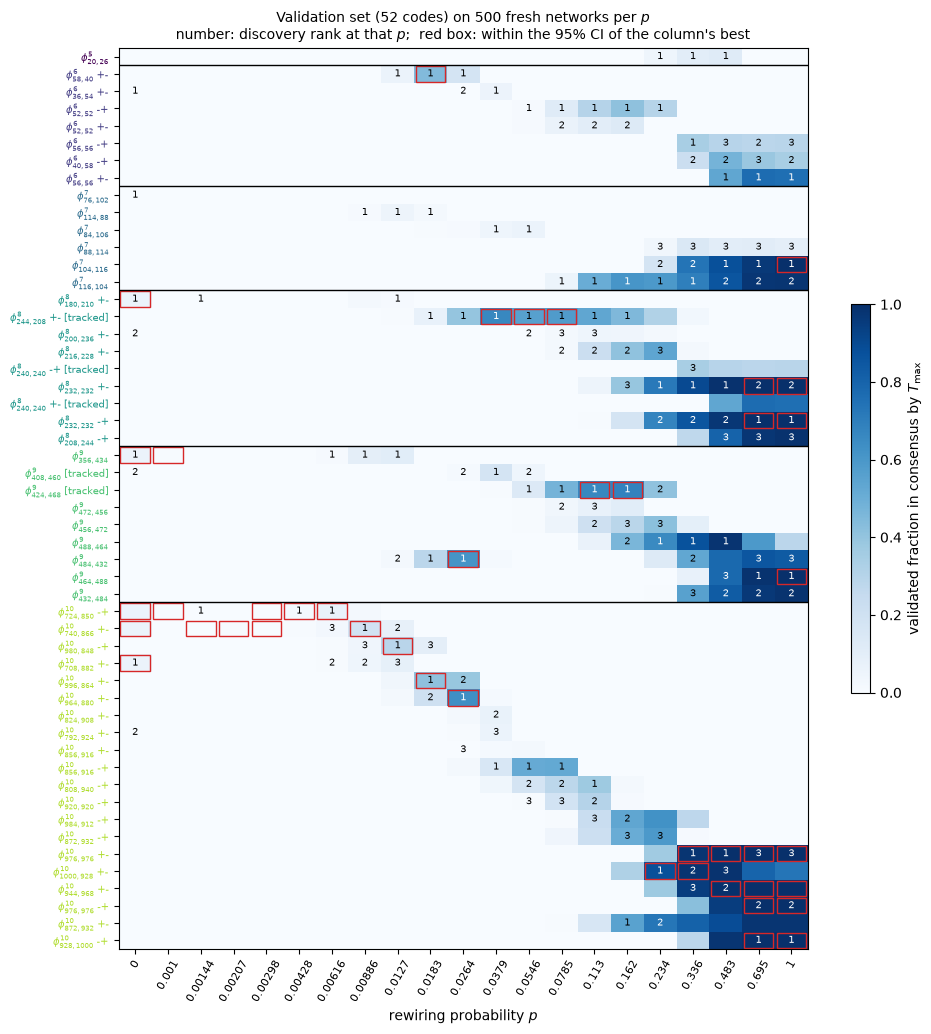

In [9]:
if not VALID_OK:
    print("section 6 skipped: no validation files")
else:
    vcodes = vset["codes"]
    F = np.array([np.isfinite(valid[i]["t_consensus"]).mean(0) for i in II_V]).T  # [code, p]: validated fraction
    best = F.max(0)
    best_ci = np.array([wilson(round(b * V), V) for b in best]).T
    within = F >= best_ci[0] - 1e-12
    rank = np.full(F.shape, 9)
    for c, i, k in zip(vset["pick_code"], vset["pick_i"], vset["pick_rank"], strict=True):
        if i in II_V:
            rank[c, II_V.index(i)] = min(rank[c, II_V.index(i)], k)
    order = np.lexsort((-F.max(1), F.argmax(1), vcodes[:, 0]))

    fig, ax = plt.subplots(figsize=(10, 1.6 + 0.17 * len(order)))
    im = ax.imshow(F[order], cmap="Blues", vmin=0, vmax=1, aspect="auto", interpolation="nearest")
    for y, c in enumerate(order):
        for x in range(len(II_V)):
            if rank[c, x] <= 3:
                ax.text(x, y, rank[c, x], ha="center", va="center", fontsize=7, color="w" if F[c, x] > 0.6 else "k")
            if within[c, x]:
                ax.add_patch(Rectangle((x - 0.45, y - 0.45), 0.9, 0.9, fill=False, ec="tab:red", lw=1))
    for y in np.flatnonzero(np.diff(vcodes[order, 0])):
        ax.axhline(y + 0.5, color="k", lw=1)
    ax.set_yticks(range(len(order)), [name(vcodes[c]) + (" [tracked]" if vset["tracked"][c] else "") for c in order],
                  fontsize=7)
    for lbl, c in zip(ax.get_yticklabels(), order, strict=True):
        lbl.set_color(R_COLOR[int(vcodes[c, 0])])
    ax.set_xticks(range(len(II_V)), [fmt_p(P[i]) for i in II_V], rotation=60, fontsize=8)
    ax.set_xlabel("rewiring probability $p$")
    fig.colorbar(im, ax=ax, shrink=min(1, 12 / len(order) + 0.2), label=r"validated fraction in consensus by $T_\mathrm{max}$")
    ax.set_title(f"Validation set ({len(order)} codes) on {V} fresh networks per $p$\n"
                 "number: discovery rank at that $p$;  red box: within the 95% CI of the column's best", fontsize=10)
    fig.tight_layout()
    plt.show()

**Per $p$: the overall winner.** The overall rank-1 discovery pick is the best behaviour over all codes; it is named by the behaviour's representative (lowest $r$, then `+-`, then smallest $\beta$), so the column "same behaviour" lists the resolutions whose codes act identically on these networks. Its validated fraction is the honest estimate; the best validated code is the column maximum of the heatmap (optimistic, see above).

| $p$ | overall rank-1 discovery pick | same behaviour | pick: discovery | pick: validated (95% CI) | majority: validated (95% CI) | best validated code(s) | best: validated (95% CI) | codes within CI of best |
|---|---|---|---|---|---|---|---|---|
| 0 | $\phi^{8}_{180,210}$ `+-` | $r$ = 8, 9, 10 (6 codes) | 0.04 | 0.060 [0.042, 0.084] | 0.346 [0.306, 0.389] | $\phi^{8}_{180,210}$ `+-`, $\phi^{9}_{356,434}$, $\phi^{10}_{708,882}$ `+-` (+2 tied) | 0.060 [0.042, 0.084] | 5 |
| 0.001 | none (no consensus on discovery) |  |  |  | 0.278 [0.241, 0.319] | $\phi^{10}_{724,850}$ `-+` | 0.006 [0.002, 0.017] | 2 |
| 0.00144 | $\phi^{8}_{180,210}$ `+-` | $r$ = 8 (1 code) | 0.01 | 0.000 [0.000, 0.008] | 0.230 [0.195, 0.269] | $\phi^{10}_{740,866}$ `+-` | 0.002 [0.000, 0.011] | 1 |
| 0.00207 | none (no consensus on discovery) |  |  |  | 0.180 [0.149, 0.216] | $\phi^{10}_{740,866}$ `+-` | 0.004 [0.001, 0.014] | 1 |
| 0.00298 | none (no consensus on discovery) |  |  |  | 0.120 [0.094, 0.151] | $\phi^{10}_{740,866}$ `+-`, $\phi^{10}_{724,850}$ `-+` | 0.002 [0.000, 0.011] | 2 |
| 0.00428 | $\phi^{10}_{724,850}$ `-+` | $r$ = 10 (1 code) | 0.01 | 0.018 [0.009, 0.034] | 0.044 [0.029, 0.066] | $\phi^{10}_{724,850}$ `-+` | 0.018 [0.009, 0.034] | 1 |
| 0.00616 | $\phi^{10}_{724,850}$ `-+` | $r$ = 10 (1 code) | 0.11 | 0.068 [0.049, 0.094] | 0.012 [0.006, 0.026] | $\phi^{10}_{724,850}$ `-+` | 0.068 [0.049, 0.094] | 1 |
| 0.00886 | $\phi^{9}_{356,434}$ | $r$ = 9 (1 code) | 0.10 | 0.094 [0.071, 0.123] | 0.004 [0.001, 0.014] | $\phi^{10}_{740,866}$ `+-` | 0.194 [0.162, 0.231] | 1 |
| 0.0127 | $\phi^{10}_{980,848}$ `-+` | $r$ = 10 (1 code) | 0.33 | 0.290 [0.252, 0.331] | 0.000 [0.000, 0.008] | $\phi^{10}_{980,848}$ `-+` | 0.290 [0.252, 0.331] | 1 |
| 0.0183 | $\phi^{6}_{58,40}$ `+-` | $r$ = 6 (1 code) | 0.47 | 0.442 [0.399, 0.486] | 0.000 [0.000, 0.008] | $\phi^{6}_{58,40}$ `+-` | 0.442 [0.399, 0.486] | 2 |
| 0.0264 | $\phi^{9}_{484,432}$ | $r$ = 9 (1 code) | 0.66 | 0.616 [0.573, 0.658] | 0.000 [0.000, 0.008] | $\phi^{10}_{964,880}$ `+-` | 0.634 [0.591, 0.675] | 2 |
| 0.0379 | $\phi^{8}_{244,208}$ `+-` | $r$ = 8 (1 code) | 0.69 | 0.664 [0.621, 0.704] | 0.000 [0.000, 0.008] | $\phi^{8}_{244,208}$ `+-` | 0.664 [0.621, 0.704] | 1 |
| 0.0546 | $\phi^{10}_{856,916}$ `-+` | $r$ = 10 (1 code) | 0.58 | 0.514 [0.470, 0.558] | 0.000 [0.000, 0.008] | $\phi^{8}_{244,208}$ `+-` | 0.562 [0.518, 0.605] | 1 |
| 0.0785 | $\phi^{8}_{244,208}$ `+-` | $r$ = 8 (1 code) | 0.65 | 0.580 [0.536, 0.622] | 0.000 [0.000, 0.008] | $\phi^{8}_{244,208}$ `+-` | 0.580 [0.536, 0.622] | 1 |
| 0.113 | $\phi^{8}_{244,208}$ `+-` | $r$ = 8 (1 code) | 0.57 | 0.534 [0.490, 0.577] | 0.000 [0.000, 0.008] | $\phi^{9}_{424,468}$ | 0.664 [0.621, 0.704] | 1 |
| 0.162 | $\phi^{9}_{424,468}$ | $r$ = 9 (1 code) | 0.66 | 0.680 [0.638, 0.719] | 0.000 [0.000, 0.008] | $\phi^{9}_{424,468}$ | 0.680 [0.638, 0.719] | 1 |
| 0.234 | $\phi^{10}_{1000,928}$ `+-` | $r$ = 10 (1 code) | 0.89 | 0.878 [0.846, 0.904] | 0.008 [0.003, 0.020] | $\phi^{10}_{1000,928}$ `+-` | 0.878 [0.846, 0.904] | 1 |
| 0.336 | $\phi^{10}_{976,976}$ `+-` | $r$ = 10 (1 code) | 0.99 | 0.980 [0.964, 0.989] | 0.624 [0.581, 0.665] | $\phi^{10}_{1000,928}$ `+-` | 0.982 [0.966, 0.991] | 2 |
| 0.483 | $\phi^{10}_{976,976}$ `+-` | $r$ = 10 (1 code) | 1.00 | 1.000 [0.992, 1.000] | 0.976 [0.959, 0.986] | $\phi^{10}_{976,976}$ `+-` | 1.000 [0.992, 1.000] | 2 |
| 0.695 | $\phi^{10}_{928,1000}$ `-+` | $r$ = 10 (1 code) | 1.00 | 0.998 [0.989, 1.000] | 0.992 [0.980, 0.997] | $\phi^{8}_{232,232}$ `+-`, $\phi^{10}_{944,968}$ `+-`, $\phi^{10}_{976,976}$ `+-` (+1 tied) | 1.000 [0.992, 1.000] | 6 |
| 1 | $\phi^{10}_{928,1000}$ `-+` | $r$ = 10 (1 code) | 1.00 | 1.000 [0.992, 1.000] | 0.998 [0.989, 1.000] | $\phi^{8}_{232,232}$ `+-`, $\phi^{8}_{232,232}$ `-+`, $\phi^{9}_{464,488}$ (+4 tied) | 1.000 [0.992, 1.000] | 8 |

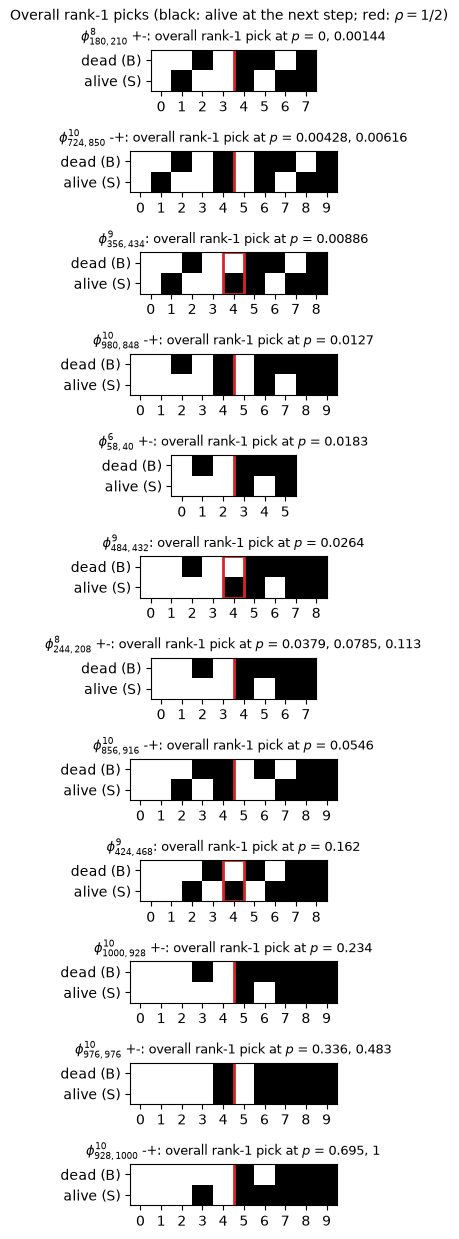

In [10]:
if not VALID_OK:
    print("section 6 skipped: no validation files")
else:
    def frac_ci(k):
        lo, hi = wilson(k, V)
        return f"{k / V:.3f} [{lo:.3f}, {hi:.3f}]"

    lines = ["| $p$ | overall rank-1 discovery pick | same behaviour | pick: discovery | pick: validated (95% CI) "
             "| majority: validated (95% CI) | best validated code(s) | best: validated (95% CI) | codes within CI of best |",
             "|---" * 9 + "|"]
    for x, i in enumerate(II_V):
        pick = lane(0, i)
        if pick is None:
            row = ["none (no consensus on discovery)", "", "", ""]
        else:
            code = VIDX[pick]
            same = CODES[disc[i]["behaviour"] == disc[i]["behaviour"][code]] if i in disc else None
            rs = "" if same is None else "$r$ = " + ", ".join(map(str, np.unique(same[:, 0]))) + f" ({len(same)} code{'s' * (len(same) > 1)})"
            dfrac = f"{FRAC_DISC[i][code]:.2f}" if i in disc else "–"
            row = [name(vcodes[pick], md=True), rs, dfrac, frac_ci(int(round(F[pick, x] * V)))]
        top = np.flatnonzero(F[:, x] == best[x])
        tops = ", ".join(name(vcodes[c], md=True) for c in top[:3]) + (f" (+{len(top) - 3} tied)" if len(top) > 3 else "")
        tops = tops if best[x] > 0 else "none (no code reaches consensus)"
        row += [frac_ci(int(np.isfinite(valid[i]["maj_t_consensus"]).sum())), tops, frac_ci(int(round(best[x] * V))),
                str(within[:, x].sum())]
        lines.append(f"| {fmt_p(P[i])} | " + " | ".join(row) + " |")
    display(Markdown("\n".join(lines)))

    picked_at = {}  # overall rank-1 pick -> its p indices (also those without files)
    for i in sorted(set(vset["pick_i"].tolist())):
        if lane(0, i) is not None:
            picked_at.setdefault(lane(0, i), []).append(i)
    if picked_at:
        fig, axes = plt.subplots(len(picked_at), 1, figsize=(6, 1.05 * len(picked_at)), squeeze=False)
        for ax, (c, ii) in zip(axes[:, 0], picked_at.items(), strict=True):
            at = [fmt_p(P[i]) if i in P else f"index {i}" for i in ii]
            show_rule(ax, vcodes[c])
            ax.set_title(f"{name(vcodes[c])}: overall rank-1 pick at $p$ = {', '.join(at)}", fontsize=9)
        fig.suptitle("Overall rank-1 picks (black: alive at the next step; red: $\\rho = 1/2$)", fontsize=10)
        fig.tight_layout()
        plt.show()

**Is the best rule the same at every $p$?** For each validation-set code, count the $p$ values at which it is within the 95% CI of the best. A code within it at every $p$ would be a candidate universal winner (a descriptive screen, not a test); the screen is trivially satisfied at a $p$ where nothing reaches consensus. The **winner changes** between two neighbouring $p$ when no code is within the CI of the best at both; this is more robust than following the column maximum, which flips among near-ties. The figure shows the codes that are within the CI most often, against the grey band of the best code's interval. Those codes are selected on validation data, so the figure is optimistic; the honest comparison with majority is section 5.

**Within the 95% CI of the best at all 21 validated $p$:** no code.

**Where the winner changes** (no code within the CI of the best at both neighbouring $p$): 0.001 → 0.00144 ($\phi^{9}_{356,434}$, $\phi^{10}_{724,850}$ `-+` → $\phi^{10}_{740,866}$ `+-`); 0.00616 → 0.00886 ($\phi^{10}_{724,850}$ `-+` → $\phi^{10}_{740,866}$ `+-`); 0.00886 → 0.0127 ($\phi^{10}_{740,866}$ `+-` → $\phi^{10}_{980,848}$ `-+`); 0.0127 → 0.0183 ($\phi^{10}_{980,848}$ `-+` → $\phi^{6}_{58,40}$ `+-`, $\phi^{10}_{996,864}$ `+-`); 0.0183 → 0.0264 ($\phi^{6}_{58,40}$ `+-`, $\phi^{10}_{996,864}$ `+-` → $\phi^{9}_{484,432}$, $\phi^{10}_{964,880}$ `+-`); 0.0264 → 0.0379 ($\phi^{9}_{484,432}$, $\phi^{10}_{964,880}$ `+-` → $\phi^{8}_{244,208}$ `+-`); 0.0785 → 0.113 ($\phi^{8}_{244,208}$ `+-` → $\phi^{9}_{424,468}$); 0.162 → 0.234 ($\phi^{9}_{424,468}$ → $\phi^{10}_{1000,928}$ `+-`).

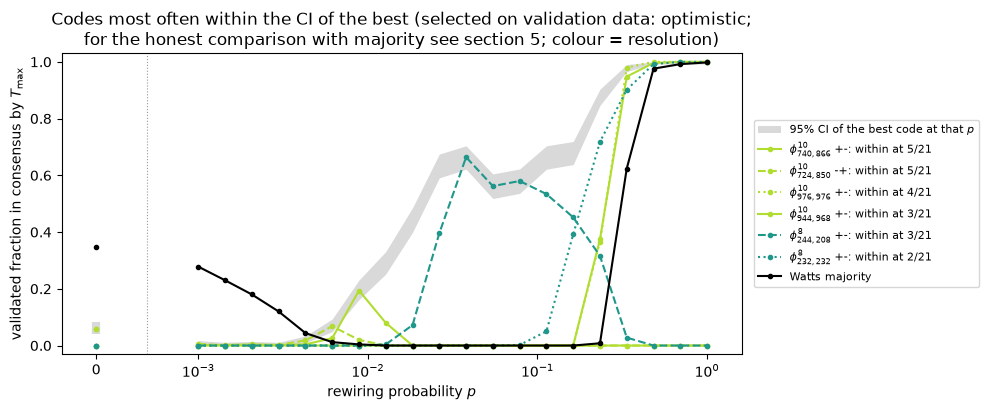

In [11]:
if not VALID_OK:
    print("section 6 skipped: no validation files")
else:
    pV = np.array([P[i] for i in II_V])
    n_within = within.sum(1)
    everywhere = np.flatnonzero(n_within == len(II_V))
    names = lambda cs: ", ".join(name(vcodes[c], md=True) for c in cs[:3]) + (f" (+{len(cs) - 3} more)" if len(cs) > 3 else "")
    breaks = [f"{fmt_p(pV[x - 1])} → {fmt_p(pV[x])} ({names(np.flatnonzero(within[:, x - 1]))} → "
              f"{names(np.flatnonzero(within[:, x]))})" for x in range(1, len(II_V))
              if not (within[:, x - 1] & within[:, x]).any()]
    display(Markdown(f"**Within the 95% CI of the best at all {len(II_V)} validated $p$:** "
                     + (names(everywhere) if everywhere.size else "no code") + ".\n\n"
                     "**Where the winner changes** (no code within the CI of the best at both neighbouring $p$): "
                     + ("; ".join(breaks) if breaks else "nowhere") + "."))
    top = np.lexsort((-F.mean(1), -n_within))[:6]
    fig, ax = plt.subplots(figsize=(10, 4.2))
    band_p(ax, pV, *best_ci, "k", alpha=0.15, label="95% CI of the best code at that $p$")
    for c in top:
        plot_p(ax, pV, F[c], color=R_COLOR[int(vcodes[c, 0])], label=f"{name(vcodes[c])}: within at {n_within[c]}/{len(II_V)}",
               ls=("-", "--", ":")[list(top).index(c) % 3])
    plot_p(ax, pV, maj_val, color="k", lw=1.5, label="Watts majority")
    p_axis(ax)
    ax.set(ylabel=r"validated fraction in consensus by $T_\mathrm{max}$", ylim=(-0.03, 1.03),
           title="Codes most often within the CI of the best (selected on validation data: optimistic;\n"
                 "for the honest comparison with majority see section 5; colour = resolution)")
    ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5))
    fig.tight_layout()
    plt.show()

## 7. Consensus time

**Distribution.** Each curve is $P(t_c \le t)$ over the $V$ validation runs: the rank-1 discovery pick of each resolution (colour) and majority (black), at up to five representative $p$. Every run is censored at the same horizon $T_\text{max}$, so this empirical CDF **is** the Kaplan–Meier estimate; nothing is known beyond $T_\text{max}$, where the curve's height is the fraction that reached consensus by $T_\text{max}$.

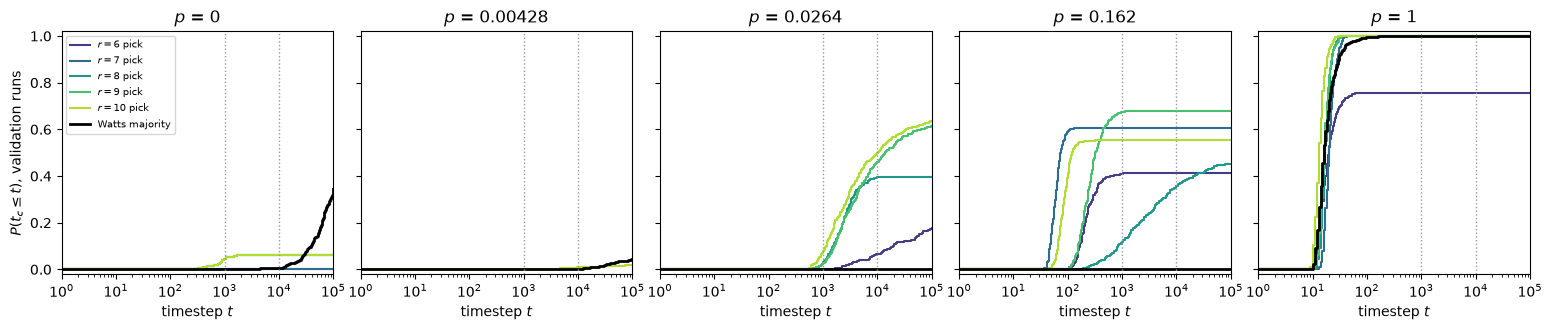

In [12]:
if not VALID_OK:
    print("section 7 skipped: no validation files")
else:
    t_grid = np.unique(np.geomspace(1, T_MAX, 400).astype(int))
    shown = [II_V[x] for x in np.unique(np.linspace(0, len(II_V) - 1, min(5, len(II_V))).round().astype(int))]
    horizons = [h for h in (1_000, 10_000) if h < T_MAX]
    fig, axes = plt.subplots(1, len(shown), figsize=(2.9 * len(shown) + 1, 3.4), sharey=True, squeeze=False)
    for ax, i in zip(axes[0], shown, strict=True):
        for r in RESOLUTIONS:
            if lane(r, i) is not None:
                t = valid[i]["t_consensus"][:, lane(r, i)]
                ax.step(t_grid, (t[:, None] <= t_grid).mean(0), where="post", color=R_COLOR[r], label=f"$r = {r}$ pick")
        t = valid[i]["maj_t_consensus"]
        ax.step(t_grid, (t[:, None] <= t_grid).mean(0), where="post", color="k", lw=2, label="Watts majority")
        for h in horizons:
            ax.axvline(h, color="0.6", ls=":", lw=1)
        ax.set(xscale="log", xlim=(1, T_MAX), title=f"$p$ = {fmt_p(P[i])}", xlabel="timestep $t$")
    axes[0, 0].set(ylabel=r"$P(t_c \leq t)$, validation runs", ylim=(-0.02, 1.02))
    axes[0, 0].legend(fontsize=7, loc="upper left")
    fig.tight_layout()
    plt.show()

**By horizon.** The fraction of validation runs in consensus by $10^3$, by $10^4$ and by $T_\text{max}$ (horizons at or beyond $T_\text{max}$ are left out), for the same picks and majority; the $T_\text{max}$ panel repeats the validated curves of section 5 without their intervals.

**Typical time when it happens.** The median $t_c$ among the runs that reached consensus by $T_\text{max}$. It is **conditional** on reaching consensus and says nothing about the runs that did not; read it together with the fractions. Points rest on at least 2% of the runs (10 at $V = 500$).

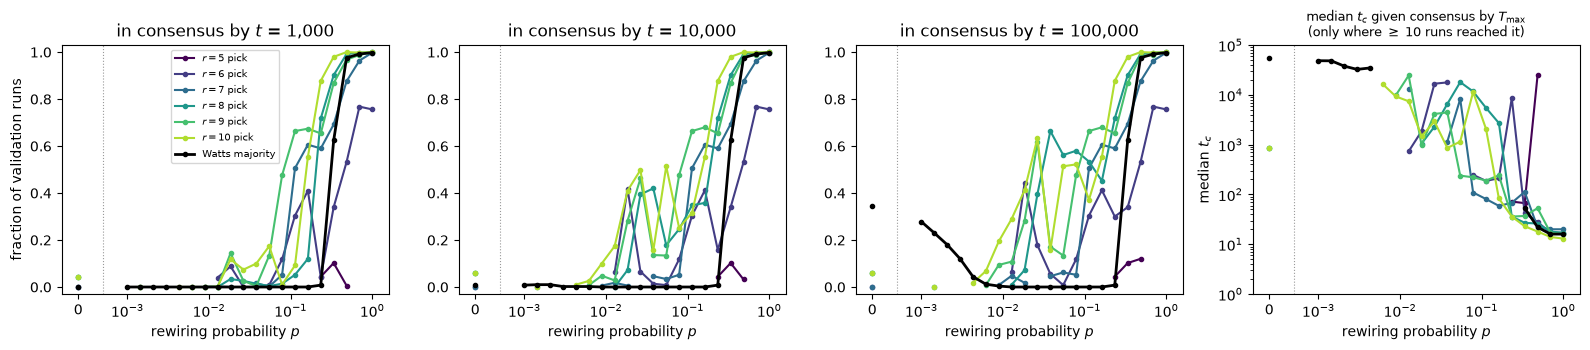

In [13]:
if not VALID_OK:
    print("section 7 skipped: no validation files")
else:
    pV = np.array([P[i] for i in II_V])
    hs = [*horizons, T_MAX]
    fig, axes = plt.subplots(1, len(hs) + 1, figsize=(4 * len(hs) + 4, 3.6))
    min_reached = max(1, V // 50)
    for r in RESOLUTIONS:
        t = np.array([valid[i]["t_consensus"][:, lane(r, i)] if lane(r, i) is not None else np.full(V, np.nan)
                      for i in II_V])  # [p, run]; nan: no pick
        for ax, h in zip(axes, hs, strict=False):
            plot_p(ax, pV, np.where(np.isnan(t[:, 0]), np.nan, (t <= h).mean(1)), color=R_COLOR[r], label=f"$r = {r}$ pick")
        reached = np.isfinite(t)
        med = [np.median(row[ok]) if ok.sum() >= min_reached else np.nan for row, ok in zip(t, reached, strict=True)]
        plot_p(axes[-1], pV, med, color=R_COLOR[r])
    t_maj = np.array([valid[i]["maj_t_consensus"] for i in II_V])
    for ax, h in zip(axes, hs, strict=False):
        plot_p(ax, pV, (t_maj <= h).mean(1), color="k", lw=2, label="Watts majority")
        ax.set(title=f"in consensus by $t$ = {h:,}", ylim=(-0.03, 1.03))
        p_axis(ax)
    med = [np.median(row[np.isfinite(row)]) if np.isfinite(row).sum() >= min_reached else np.nan for row in t_maj]
    plot_p(axes[-1], pV, med, color="k", lw=2)
    axes[0].set_ylabel("fraction of validation runs")
    axes[0].legend(fontsize=7)
    axes[-1].set(yscale="log", ylim=(1, T_MAX), ylabel="median $t_c$",
                 title=f"median $t_c$ given consensus by $T_\\mathrm{{max}}$\n(only where $\\geq$ {min_reached} runs reached it)")
    axes[-1].title.set_fontsize(9)
    p_axis(axes[-1])
    fig.tight_layout()
    plt.show()

## 8. Conclusions and caveats

### Conclusions

These conclusions are for the full run: $N = 1000$, $k = 8$, $\rho^0 = 1/2$, $T_\text{max} = 10^5$.
- **Validated** means the rank-1 pick of the 100 discovery networks, measured on 500 fresh networks at the same $p$.
- **Consensus** means consensus by $T_\text{max}$.
- **Paired counts** "$a : b$" are from section 5: the rule reached consensus earlier on $a$ networks and later on $b$.

**1. There are three regimes, and the LLNA rules beat majority in only one of them.**

**Near-ring, $p \le 0.003$** (at least 97.6% of nodes have degree 8). Watts' majority is better here.
- Majority reaches consensus in 34.6% of networks at $p = 0$, falling to 12.0% at $p = 0.003$.
- The best rules are far behind:
  - at $p = 0$, 6.0% of networks. This is $\phi^8_{180,210}$ `+-`, which is the same behaviour as the picks of $r = 9$ and $r = 10$.
  - for $0.001 \le p \le 0.003$, at most 0.6% of networks.
- At $p = 0$, every resolution's pick loses the paired comparison: $30 : 163$ for $r = 8$–$10$, Holm $p \approx 10^{-22}$.
- Majority's successes are slow. At most 1% come by $10^4$ steps, conditional medians are $3.3$–$5.5 \times 10^4$, and its curves are still rising at $T_\text{max}$. Its fractions here are therefore lower bounds.
- About 53% of all rule runs at these $p$ provably end in a cycle without consensus, and about 46% are open.

**Small world, $0.006 \lesssim p \le 0.23$.** Rules reach consensus where majority does not.
- Majority falls from 4.4% ($p = 0.0043$) to 1.2% ($0.0062$), and reaches consensus on none of the 500 networks for $0.0127 \le p \le 0.162$. It reaches 0.8% at $0.234$.
- The first $p$ at which a rule is significantly better is $0.0062$: $\phi^{10}_{724,850}$ `-+` reaches 6.8% against majority's 1.2% ($34 : 4$, Holm $p = 1.2 \times 10^{-6}$). At $0.0043$ majority is still ahead: 4.4% against 1.8%.
- From there the validated pick climbs:
  - 29% at $p = 0.0127$ ($\phi^{10}_{980,848}$ `-+`);
  - 44% at $0.0183$ ($\phi^{6}_{58,40}$ `+-`);
  - 62% at $0.0264$ ($\phi^{9}_{484,432}$);
  - 66% at $0.0379$ ($\phi^{8}_{244,208}$ `+-`);
  - 68% at $0.162$ ($\phi^{9}_{424,468}$);
  - 88% at $0.234$ ($\phi^{10}_{1000,928}$ `+-`).
- Between $p = 0.0127$ and $0.162$ no pick of any resolution loses a single paired comparison with majority. A few picks are not significant after Holm, because they reach consensus on only a handful of networks.

**Random-like, $p \ge 0.34$.** Both reach consensus, and the best rules are faster.
- Majority jumps from 0.8% ($p = 0.234$) to 62.4% ($0.336$), and reaches at least 97.6% for $p \ge 0.48$.
- At $p = 0.336$, $\phi^{10}_{976,976}$ `+-` reaches 98.0% against majority's 62.4%.
- For $p \ge 0.48$, both are near 100%. There the $r = 10$ picks reach consensus earlier in paired runs ($315 : 160$, $320 : 150$ and $339 : 117$ at $p = 0.48$, $0.70$ and $1$; Holm $p \le 3 \times 10^{-12}$). The gain is a few steps: at $p = 1$ the medians are 13 against 16.

**2. The best rule changes with $p$, and the winners are specialists.**
- No validation-set code is within the 95% CI of the best at every $p$, and the winner changes eight times along the axis (section 6).
- Several winners are sharply tuned. At $p = 0.0183$, $0.0264$ and $0.0379$:
  - $\phi^{10}_{964,880}$ `+-` goes from 21% to 63% to 1%;
  - $\phi^{9}_{484,432}$ goes from 28% to 62% to 1%, though it recovers to 53–85% for $p \ge 0.34$.
  - Both curves agree between discovery and validation networks, so this is a property of the rules, not sampling noise.
- The most robust rule in the window is $\phi^{8}_{244,208}$ `+-`, the winner of `consensus_r8.ipynb`.
  - It reaches at least 40% at every $p$ from $0.0264$ to $0.162$, with a peak of 66% at $0.0379$.
  - It is below 1% for $p \le 0.0127$ and for $p \ge 0.48$.
- Next most robust is $\phi^{9}_{424,468}$: 48–68% for $0.0785 \le p \le 0.162$.

**3. Finer resolution gives no monotone gain.**
- At $p = 0$ resolution beyond $r = 9$ is irrelevant. The 1680 codes are 256 behaviours, and the picks of $r = 8$, $9$ and $10$ coincide.
- Over the 18 values of $p$ with a pick, the overall rank-1 pick has:
  - $r = 10$ at 9 of them;
  - $r = 8$ at 5;
  - $r = 9$ at 3;
  - $r = 6$ at 1.
- This count is not evidence that finer cells help. $r = 10$ has 768 distinct rules against 192 for $r = 8$ and 256 for $r = 9$, so it simply has more chances to contain a specialist.
- At the low end, $r = 5$ reaches no consensus below $p = 0.234$ and peaks near 12%. The best $r = 6$ rules level off near 76% at large $p$, below majority.
- Resolutions $r = 7$–$10$ reach similar peak levels in the window.

**4. Time to consensus.**
- Inside the window, consensus is slow at small $p$ and fast at large $p$. The validated picks have median $t_c$:
  - about $1.9 \times 10^3$ at $p = 0.0183$;
  - about $4.1 \times 10^3$ at $p = 0.0264$;
  - about $6.6 \times 10^3$ at $p = 0.0379$;
  - 242 at $p = 0.162$;
  - 36 at $p = 0.234$.
- At $p = 0.0264$ and $0.0379$, a quarter and a third of the successful runs reach consensus after $10^4$ steps. A $10^4$ horizon would have missed them.
- In the random-like regime, both rules and majority need 13–54 steps (medians).

**5. So what.**
- Where Watts' majority freezes, in the small-world window, deterministic self-symmetric LLNA rules do reach consensus, on up to 66–88% of fresh networks.
- But only rules tuned to that $p$ do so. No rule is good across the regimes.
- On near-rings, majority's coin at ties gets further within $10^5$ steps than any deterministic quiescent self-symmetric rule.
- Two questions are left open:
  - what makes rules like $\phi^8_{244,208}$ (majority with keep-on-tie plus two exceptions near the threshold) the most robust;
  - whether a stochastic LLNA rule could combine majority's slow coarsening on near-rings with this window performance.

**Sanity check.** The 45,001 validated consensus runs end alive in 49.7% of cases, as the symmetry of the rules and of $\rho^0 = 1/2$ requires.

### Caveats

- **Horizon censoring at low $p$.** On the ring and at small $p$, consensus needs domains to coarsen across the whole ring; with diffusing domain walls that takes on the order of $N^2/4$ steps ($2.5 \times 10^5$ at $N = 1000$, beyond $T_\text{max} = 10^5$). "No consensus by $T_\text{max}$" there can be a statement about the horizon rather than about the rule.
- **$p = 0$ has a single network.** At $p = 0$ nothing is rewired, so every seed gives the same ring lattice; only the initial states differ between runs.
- **Fixed $N$, $k$ and $\rho^0$.** All results are for $N = 1000$, $k = 8$ and exactly $\rho^0 = 1/2$, which leaves no initial majority to amplify. Other sizes, degrees or initial densities can rank the rules differently.
- **Majority has one noise realisation per network.** Its coin flips at ties come from one seed per stage, so its fraction is over networks with a single noise path each.
- **Cycle detection is exact but bounded.** A cycle with transient $\mu$ and period $\lambda$ is found when some power of two $2^j \ge \mu$ with $2^j \ge \lambda$ satisfies $2^j + \lambda \le T_\text{max}$. At $T_\text{max} = 10^5$ a cycle entered after $t = 65\,536$ (or with a period above $34\,464$) goes unseen, so "open" includes such runs: it is an upper bound on the runs that had entered neither consensus nor a cycle by $T_\text{max}$.
- **Winner's curse.** Picks are chosen on the $S = 100$ discovery networks and measured on $V = 500$ fresh ones; only validated numbers are used to compare the winners with majority. Section 6 is the exception: its column maximum and its "most often within the CI" codes are selected on validation data and are optimistic, as flagged there.
- **Multiple testing.** Holm's correction is applied across $p$ within each resolution, not across resolutions.
- **Counting.** Section 4 counts codes; for even $r$ a rule shared by both conventions is counted twice.